# **Bike Sharing Systems - Exploratory Data Analysis with ggplot2**

This notebook performs visual exploratory analysis on the Seoul bike sharing
demand dataset using tidyverse and ggplot2. Key questions addressed:

- How does bike demand vary across time, season, and hour of day?
- Which weather variables correlate most strongly with rental counts?
- What does the distribution of demand look like, and are there outliers?

Findings from this analysis inform the feature selection and modeling steps
of the pipeline.

## **Setup**

In [ ]:
library(tidyverse)
library(ggplot2)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## **Load and Prepare Data**

Load the Seoul bike sharing dataset, parse dates, and cast categorical
variables to the correct types. `HOUR` is treated as an ordered factor
to ensure correct ordering in visualizations.

In [ ]:
seoul_bike_sharing <- read_csv(
  "seoul_bike_sharing.csv",
  col_types = cols(DATE = col_character()),
  show_col_types = FALSE
)

seoul_bike_sharing <- seoul_bike_sharing %>%
  mutate(
    DATE    = as.Date(DATE, format = "%d/%m/%Y"),
    HOUR    = factor(HOUR, levels = 0:23, ordered = TRUE),
    SEASONS = factor(SEASONS),
    HOLIDAY = factor(HOLIDAY)
  )

str(seoul_bike_sharing)

tibble [8,465 × 14] (S3: tbl_df/tbl/data.frame)
 $ DATE                 : Date[1:8465], format: "2017-12-01" "2017-12-01" ...
 $ RENTED_BIKE_COUNT    : num [1:8465] 254 204 173 107 78 100 181 460 930 490 ...
 $ HOUR                 : Ord.factor w/ 24 levels "0"<"1"<"2"<"3"<..: 1 2 3 4 5 6 7 8 9 10 ...
 $ TEMPERATURE          : num [1:8465] -5.2 -5.5 -6 -6.2 -6 -6.4 -6.6 -7.4 -7.6 -6.5 ...
 $ HUMIDITY             : num [1:8465] 37 38 39 40 36 37 35 38 37 27 ...
 $ WIND_SPEED           : num [1:8465] 2.2 0.8 1 0.9 2.3 1.5 1.3 0.9 1.1 0.5 ...
 $ VISIBILITY           : num [1:8465] 2000 2000 2000 2000 2000 ...
 $ DEW_POINT_TEMPERATURE: num [1:8465] -17.6 -17.6 -17.7 -17.6 -18.6 -18.7 -19.5 -19.3 -19.8 -22.4 ...
 $ SOLAR_RADIATION      : num [1:8465] 0 0 0 0 0 0 0 0 0.01 0.23 ...
 $ RAINFALL             : num [1:8465] 0 0 0 0 0 0 0 0 0 0 ...
 $ SNOWFALL             : num [1:8465] 0 0 0 0 0 0 0 0 0 0 ...
 $ SEASONS              : Factor w/ 4 levels "Autumn","Spring",..: 4 4 4 4 4 4 4 4 4 4 .

## **Missing Values Check**

In [ ]:
sum(is.na(seoul_bike_sharing))

[1] 0

## **Descriptive Statistics**

A high level summary of the dataset.

In [ ]:
summary(seoul_bike_sharing)

      DATE            RENTED_BIKE_COUNT      HOUR       TEMPERATURE    
 Min.   :2017-12-01   Min.   :   2.0    7      : 353   Min.   :-17.80  
 1st Qu.:2018-02-27   1st Qu.: 214.0    8      : 353   1st Qu.:  3.00  
 Median :2018-05-28   Median : 542.0    9      : 353   Median : 13.50  
 Mean   :2018-05-28   Mean   : 729.2    10     : 353   Mean   : 12.77  
 3rd Qu.:2018-08-24   3rd Qu.:1084.0    11     : 353   3rd Qu.: 22.70  
 Max.   :2018-11-30   Max.   :3556.0    12     : 353   Max.   : 39.40  
                                        (Other):6347                   
    HUMIDITY       WIND_SPEED      VISIBILITY   DEW_POINT_TEMPERATURE
 Min.   : 0.00   Min.   :0.000   Min.   :  27   Min.   :-30.600      
 1st Qu.:42.00   1st Qu.:0.900   1st Qu.: 935   1st Qu.: -5.100      
 Median :57.00   Median :1.500   Median :1690   Median :  4.700      
 Mean   :58.15   Mean   :1.726   Mean   :1434   Mean   :  3.945      
 3rd Qu.:74.00   3rd Qu.:2.300   3rd Qu.:2000   3rd Qu.: 15.200      
 Max

**Key observations:**

- The dataset covers exactly one full year of hourly records.
- Temperature spans a wide range, which is a strong signal it will be a
  useful predictor of demand.
- Rainfall and snowfall are rare events, showing up only in the upper quartiles.
- Wind speed is consistently light, averaging around 1.7 m/s across the year.

## **Holiday Statistics**

In [ ]:
# Count of holiday records
holiday_count <- seoul_bike_sharing %>%
  filter(HOLIDAY == "Holiday") %>%
  nrow()

# Percentage of records falling on a holiday
holiday_pct <- round(100 * holiday_count / nrow(seoul_bike_sharing), 2)

cat("Holiday records:", holiday_count, "\n")
cat("Holiday percentage:", holiday_pct, "%\n")

Holiday records: 408 
Holiday percentage: 4.82 %


## **Expected vs Actual Record Count**

With exactly one full year of hourly data, we expect 365 x 24 = 8,760 records.
The actual count reflects records removed during missing value handling.

In [ ]:
expected <- 365 * 24
actual   <- nrow(seoul_bike_sharing)

cat("Expected records:", expected, "\n")
cat("Actual records:  ", actual,   "\n")
cat("Difference:      ", expected - actual, "\n")

Expected records: 8760 
Actual records:   8465 
Difference:       295 


## **Seasonal Precipitation**

Total rainfall and snowfall aggregated by season.

In [ ]:
seoul_bike_sharing %>%
  group_by(SEASONS) %>%
  summarise(
    TOTAL_RAINFALL = sum(RAINFALL, na.rm = TRUE),
    TOTAL_SNOWFALL = sum(SNOWFALL, na.rm = TRUE)
  ) %>%
  arrange(desc(TOTAL_RAINFALL))

SEASONS,TOTAL_RAINFALL,TOTAL_SNOWFALL
<fct>,<dbl>,<dbl>
Summer,559.7,0.0
Spring,403.8,0.0
Autumn,227.9,123.0
Winter,70.9,534.6


## **Demand Over Time**

A scatter plot of hourly bike rentals across the full year. The seasonal
pattern is immediately visible, with demand peaking in summer and dropping
sharply in winter.

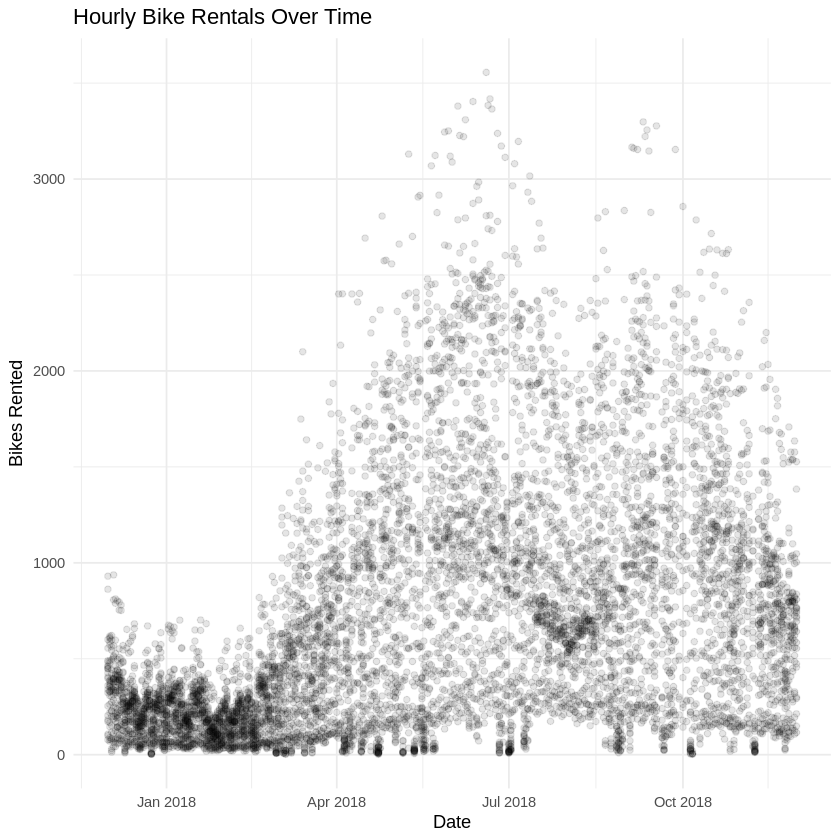

In [ ]:
ggplot(seoul_bike_sharing, aes(x = DATE, y = RENTED_BIKE_COUNT)) +
  geom_point(alpha = 0.1) +
  labs(
    title = "Hourly Bike Rentals Over Time",
    x     = "Date",
    y     = "Bikes Rented"
  ) +
  theme_minimal()

## **Demand Over Time by Hour**

Adding hour of day as colour reveals the within-day structure of demand.
Morning and evening commute peaks are clearly visible across the year.

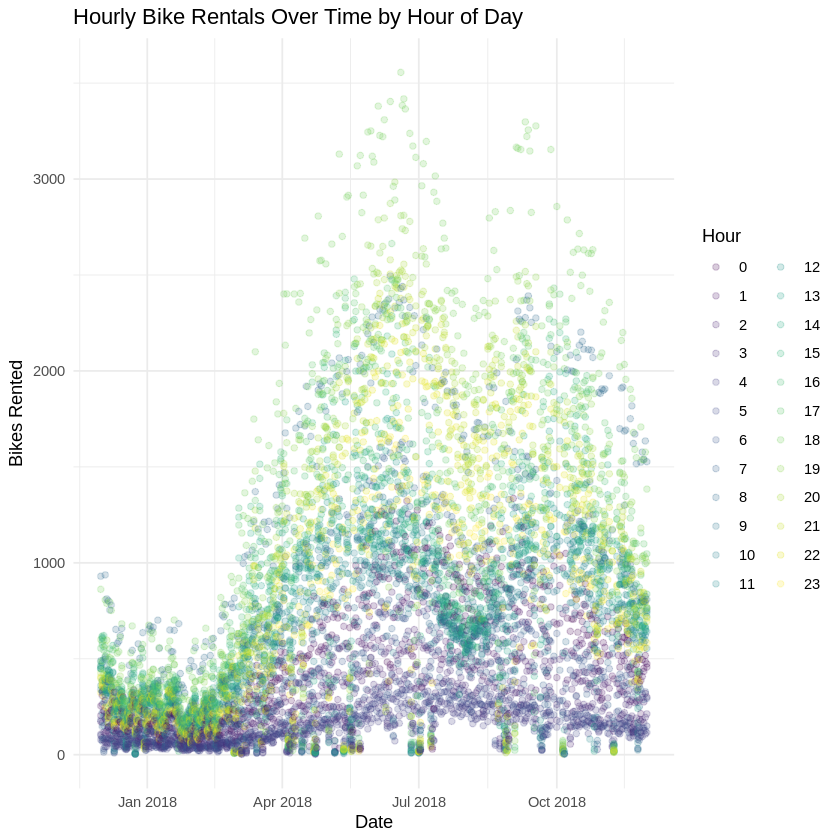

In [ ]:
ggplot(seoul_bike_sharing, aes(x = DATE, y = RENTED_BIKE_COUNT, colour = HOUR)) +
  geom_point(alpha = 0.2) +
  labs(
    title  = "Hourly Bike Rentals Over Time by Hour of Day",
    x      = "Date",
    y      = "Bikes Rented",
    colour = "Hour"
  ) +
  theme_minimal()

## **Demand Distribution**

The distribution of hourly bike rentals is right-skewed. The mode is around
250 bikes, but secondary peaks suggest distinct demand subgroups, likely
driven by season and time of day.

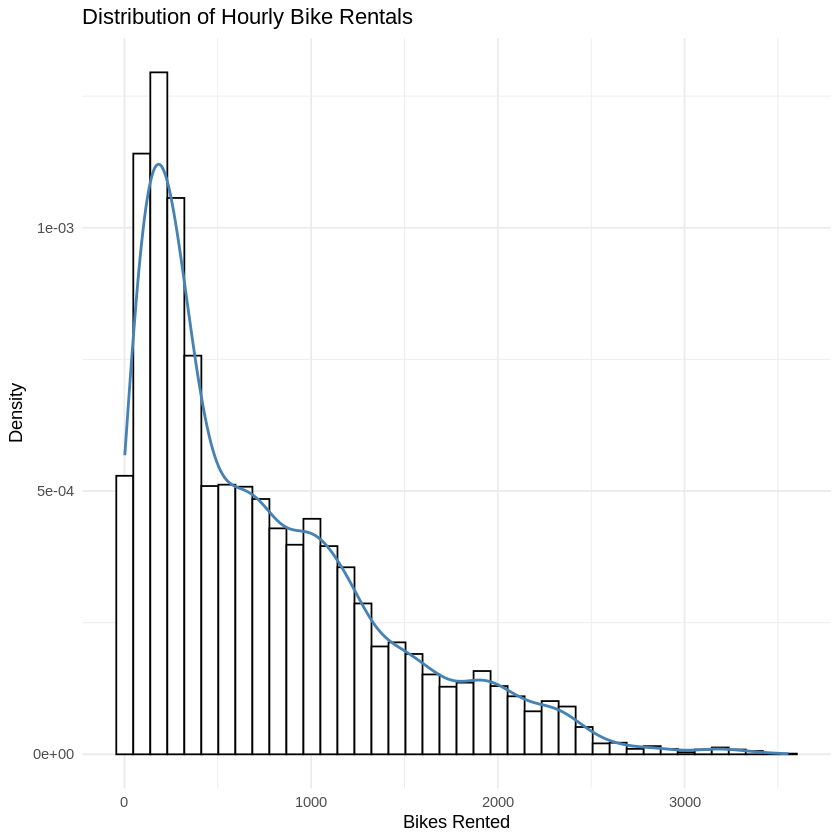

In [ ]:
ggplot(seoul_bike_sharing, aes(x = RENTED_BIKE_COUNT)) +
  geom_histogram(aes(y = after_stat(density)),
                 colour = "black", fill = "white", bins = 40) +
  geom_density(colour = "steelblue", linewidth = 0.8, alpha = 0.6) +
  labs(
    title = "Distribution of Hourly Bike Rentals",
    x     = "Bikes Rented",
    y     = "Density"
  ) +
  theme_minimal()

## **Demand vs Temperature by Season**

Bike demand correlates positively with temperature within each season.
The relationship is strongest in spring and autumn. Colour by hour shows
that peak demand hours drive much of the variation.

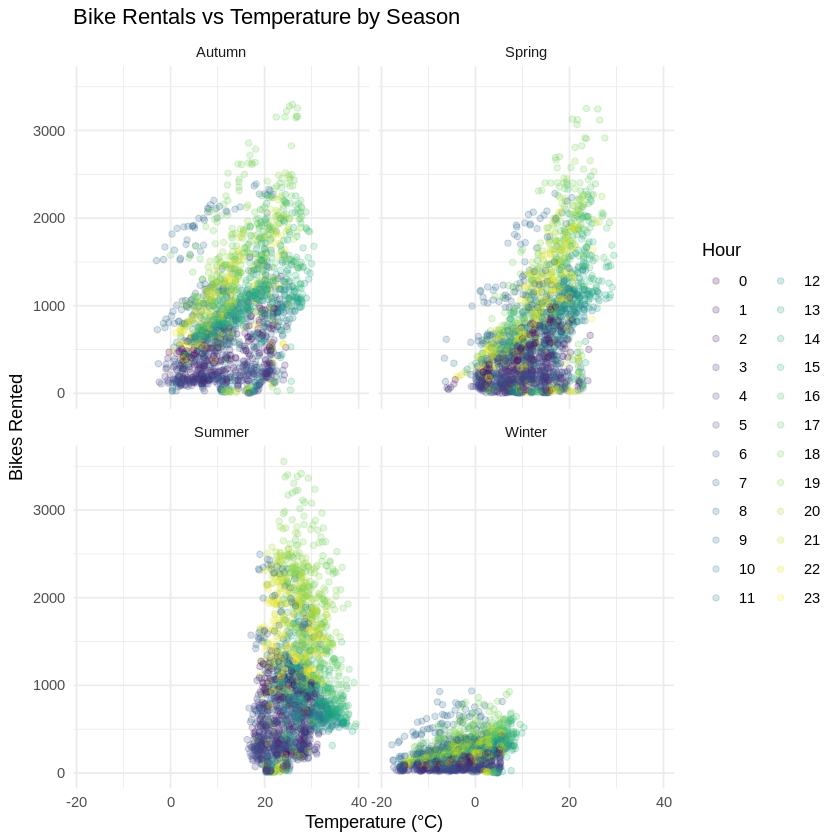

In [ ]:
ggplot(seoul_bike_sharing, aes(x = TEMPERATURE, y = RENTED_BIKE_COUNT, colour = HOUR)) +
  geom_point(alpha = 0.2) +
  facet_wrap(~ SEASONS) +
  labs(
    title  = "Bike Rentals vs Temperature by Season",
    x      = "Temperature (°C)",
    y      = "Bikes Rented",
    colour = "Hour"
  ) +
  theme_minimal()

## **Demand vs Temperature - No Season Grouping**

Without season grouping, the temperature-demand relationship appears weaker,
illustrating the importance of seasonality as a confounding factor.

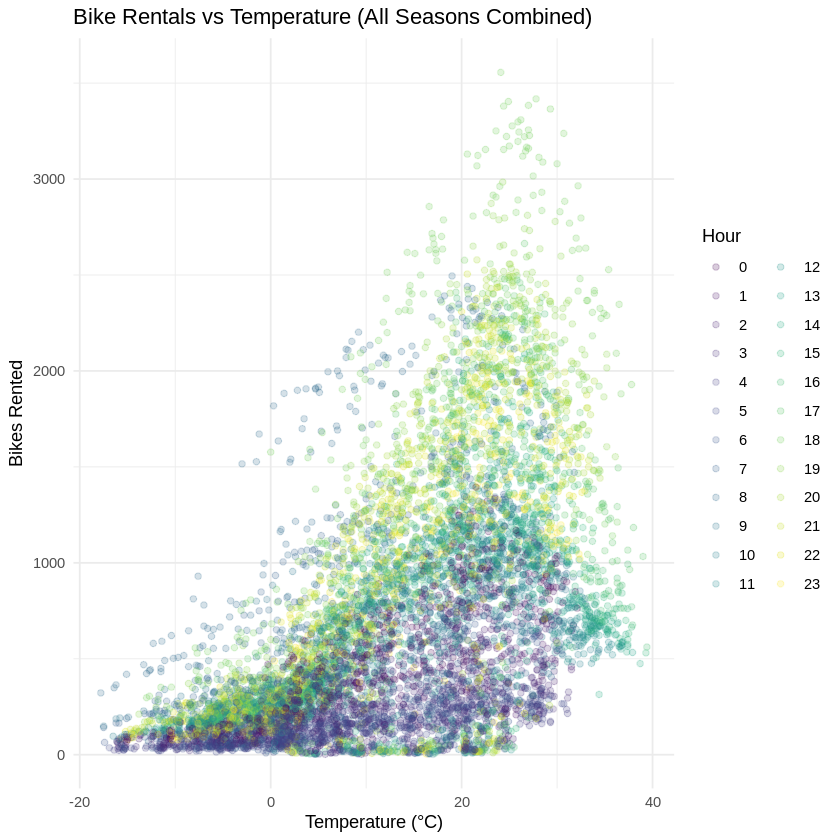

In [ ]:
ggplot(seoul_bike_sharing, aes(x = TEMPERATURE, y = RENTED_BIKE_COUNT, colour = HOUR)) +
  geom_point(alpha = 0.2) +
  labs(
    title  = "Bike Rentals vs Temperature (All Seasons Combined)",
    x      = "Temperature (°C)",
    y      = "Bikes Rented",
    colour = "Hour"
  ) +
  theme_minimal()

## **Hourly Demand Boxplots by Season**

Peak demand hours (8am and 6pm) are consistent across all seasons, reflecting
commuting patterns. The overall scale of demand shifts significantly with
season, being highest in summer and lowest in winter.

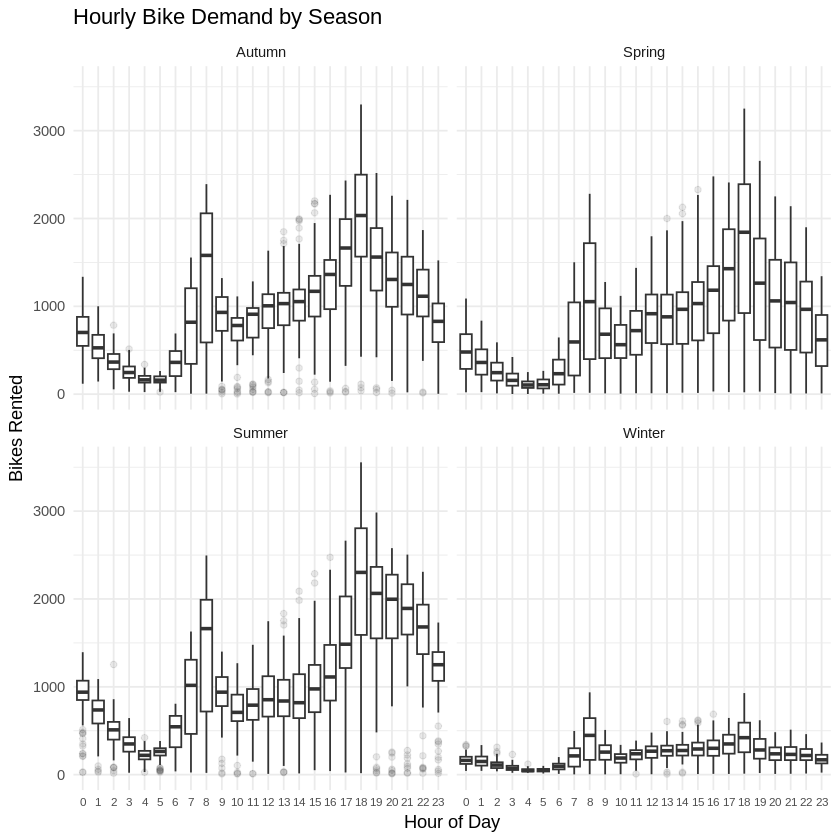

In [ ]:
ggplot(seoul_bike_sharing, aes(x = HOUR, y = RENTED_BIKE_COUNT)) +
  geom_boxplot(outlier.alpha = 0.1) +
  facet_wrap(~ SEASONS) +
  labs(
    title = "Hourly Bike Demand by Season",
    x     = "Hour of Day",
    y     = "Bikes Rented"
  ) +
  theme_minimal() +
  theme(axis.text.x = element_text(size = 7))

## **Daily Precipitation**

Total daily rainfall and snowfall across the year. Precipitation is heavily
concentrated in summer for rain and winter for snow.

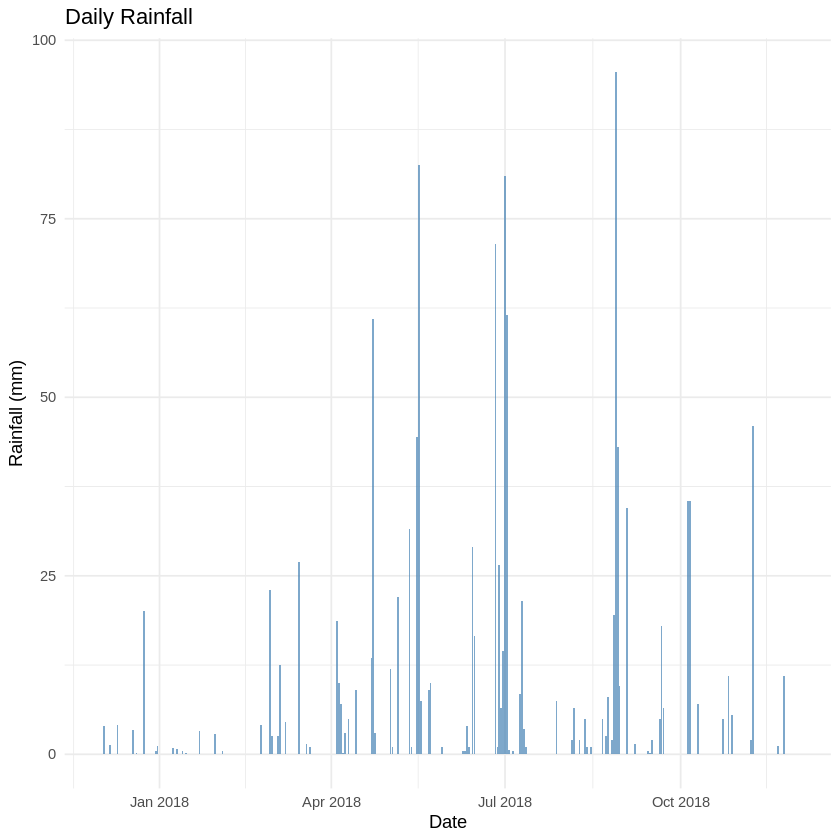

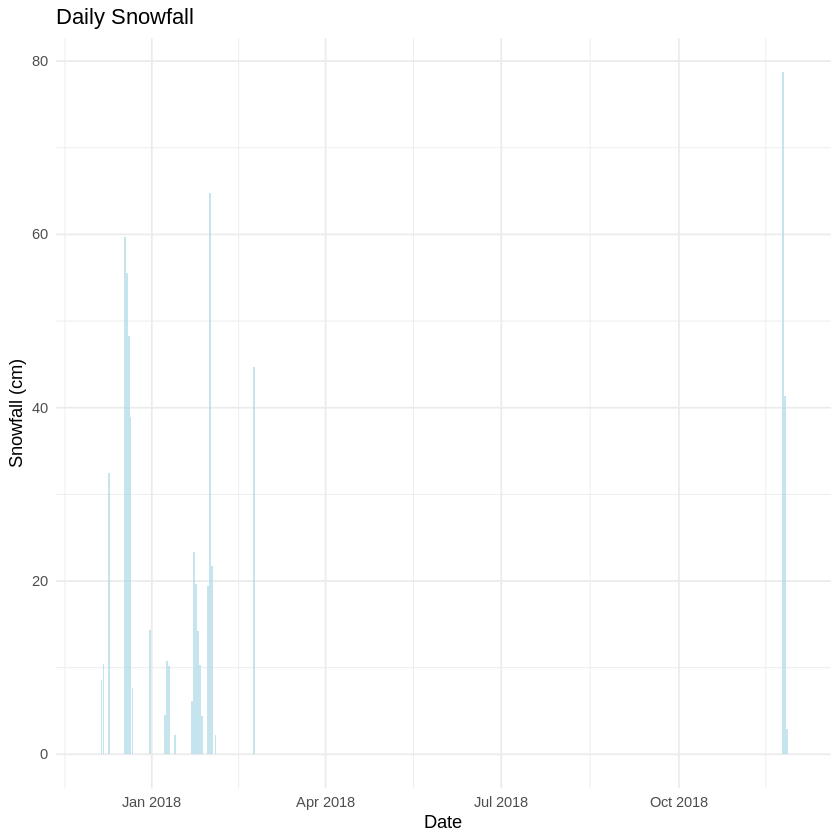

In [ ]:
daily_precip <- seoul_bike_sharing %>%
  group_by(DATE) %>%
  summarise(
    TOTAL_RAINFALL = sum(RAINFALL, na.rm = TRUE),
    TOTAL_SNOWFALL = sum(SNOWFALL, na.rm = TRUE)
  )

ggplot(daily_precip, aes(x = DATE)) +
  geom_col(aes(y = TOTAL_RAINFALL), fill = "steelblue", alpha = 0.7) +
  labs(
    title = "Daily Rainfall",
    x     = "Date",
    y     = "Rainfall (mm)"
  ) +
  theme_minimal()

ggplot(daily_precip, aes(x = DATE)) +
  geom_col(aes(y = TOTAL_SNOWFALL), fill = "lightblue", alpha = 0.7) +
  labs(
    title = "Daily Snowfall",
    x     = "Date",
    y     = "Snowfall (cm)"
  ) +
  theme_minimal()

## **Days with Snowfall**

In [ ]:
snowy_days <- daily_precip %>%
  filter(TOTAL_SNOWFALL > 0) %>%
  nrow()

cat("Days with snowfall:", snowy_days)

Days with snowfall: 27